In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
data = pd.read_csv('Fiserv_data_2019-01-01_to_2024-01-01.csv')

In [3]:
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127808 entries, 0 to 127807
Data columns (total 16 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Period                     127808 non-null  int64  
 1   Geo                        127808 non-null  object 
 2   Sector Name                127808 non-null  object 
 3   Sub-Sector Name            127808 non-null  object 
 4   Sales Index - SA           127442 non-null  float64
 5   Transactional Index - SA   127259 non-null  float64
 6   Sales MOM % - SA           125836 non-null  float64
 7   Sales YOY % - SA           124422 non-null  float64
 8   Transaction MOM % - SA     125653 non-null  float64
 9   Transaction YOY %  - SA    124275 non-null  float64
 10  Sales Index - NSA          127808 non-null  float64
 11  Transactional Index - NSA  127808 non-null  float64
 12  Sales MOM % - NSA          126201 non-null  float64
 13  Sales YOY % - NSA          12

,Period,Geo,Sector Name,Sub-Sector Name,Sales Index - SA,Transactional Index - SA,Sales MOM % - SA,Sales YOY % - SA,Transaction MOM % - SA,Transaction YOY % - SA,Sales Index - NSA,Transactional Index - NSA,Sales MOM % - NSA,Sales YOY % - NSA,Transaction MOM % - NSA,Transaction YOY % - NSA
0,20190101,Atlanta-Sandy Springs-Alpharetta GA,All,All,95.60,95.90,0.0,0.0,0.0,0.0,90.67,90.13,0.0,0.0,0.0,0.0
1,20190101,Boston-Cambridge-Newton MA-NH,All,All,97.42,95.22,0.0,0.0,0.0,0.0,87.93,85.77,0.0,0.0,0.0,0.0
2,20190101,Chicago-Naperville-Elgin IL-IN-WI,All,All,94.16,95.72,0.0,0.0,0.0,0.0,85.68,84.17,0.0,0.0,0.0,0.0
3,20190101,Dallas-Fort Worth-Arlington TX,All,All,99.46,98.85,0.0,0.0,0.0,0.0,92.87,92.49,0.0,0.0,0.0,0.0
4,20190101,Los Angeles-Long Beach-Anaheim CA,All,All,95.18,97.59,0.0,0.0,0.0,0.0,91.52,93.10,0.0,0.0,0.0,0.0


In [4]:
data.isnull().sum()

Period                          0
Geo                             0
Sector Name                     0
Sub-Sector Name                 0
Sales Index - SA              366
Transactional Index - SA      549
Sales MOM % - SA             1972
Sales YOY % - SA             3386
Transaction MOM % - SA       2155
Transaction YOY %  - SA      3533
Sales Index - NSA               0
Transactional Index - NSA       0
Sales MOM % - NSA            1607
Sales YOY % - NSA            3021
Transaction MOM % - NSA      1607
Transaction YOY % - NSA      3021
dtype: int64

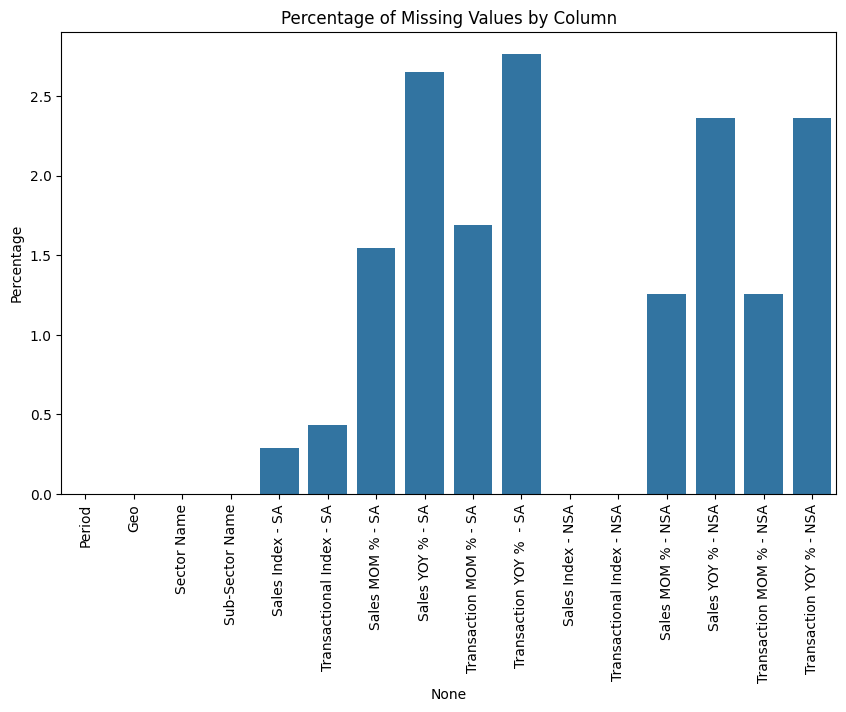

In [5]:
# Calculating the percentage of missing values in each column
missing_values = data.isnull().mean() * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values)
plt.xticks(rotation=90)
plt.title('Percentage of Missing Values by Column')
plt.ylabel('Percentage')
plt.show()


#### Data Cleaning: Handling Missing Values

In [6]:
#Filling the missing values by the mean of the column for large number of null values
sy_mean = data['Sales YOY % - SA'].mean()
data['Sales YOY % - SA'].fillna(sy_mean, inplace=True)
tm_mean= data['Transaction MOM % - SA'].mean()
data['Transaction MOM % - SA'].fillna(tm_mean, inplace=True)
ty_mean= data['Transaction YOY %  - SA'].mean()
data['Transaction YOY %  - SA'].fillna(ty_mean, inplace=True)
syn_mean = data['Sales YOY % - NSA'].mean()
data['Sales YOY % - NSA'].fillna(syn_mean, inplace=True)
tyn_mean= data['Transaction YOY % - NSA'].mean()
data['Transaction YOY % - NSA'].fillna(tyn_mean, inplace=True)

C:\Users\kanna\AppData\Local\Temp\ipykernel_13512\1992208722.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Sales YOY % - SA'].fillna(sy_mean, inplace=True)
C:\Users\kanna\AppData\Local\Temp\ipykernel_13512\1992208722.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [7]:
#Dropping the missing rows of rest of null values
data=data.dropna(subset=['Sales Index - SA'])
data=data.dropna(subset=['Transactional Index - SA'])
data=data.dropna(subset= ['Sales MOM % - SA'])
data=data.dropna(subset=['Sales MOM % - NSA'])
data=data.dropna(subset=['Transaction MOM % - NSA'])

In [8]:
data.isnull().sum()

Period                       0
Geo                          0
Sector Name                  0
Sub-Sector Name              0
Sales Index - SA             0
Transactional Index - SA     0
Sales MOM % - SA             0
Sales YOY % - SA             0
Transaction MOM % - SA       0
Transaction YOY %  - SA      0
Sales Index - NSA            0
Transactional Index - NSA    0
Sales MOM % - NSA            0
Sales YOY % - NSA            0
Transaction MOM % - NSA      0
Transaction YOY % - NSA      0
dtype: int64

#### Data Cleaning: Date Component Extraction

In [9]:
## Converting the 'Period' column from string format (YYYYMMDD) to a datetime object for easier date manipulation and analysis.
data['Period'] = pd.to_datetime(data['Period'], format='%Y%m%d')

In [10]:
# creating a new column in the data for year, month and date
data['Year'] = data['Period'].dt.year
data['Month'] = data['Period'].dt.month
data['Day'] = data['Period'].dt.day
print(data[['Period', 'Year', 'Month', 'Day']].head())

      Period  Year  Month  Day
0 2019-01-01  2019      1    1
1 2019-01-01  2019      1    1
2 2019-01-01  2019      1    1
3 2019-01-01  2019      1    1
4 2019-01-01  2019      1    1


#### Data Cleaning: Feature Elimination

In [11]:
data=data.drop(['Day','Period'],axis=1)

In [12]:
data.head()

,Geo,Sector Name,Sub-Sector Name,Sales Index - SA,Transactional Index - SA,Sales MOM % - SA,Sales YOY % - SA,Transaction MOM % - SA,Transaction YOY % - SA,Sales Index - NSA,Transactional Index - NSA,Sales MOM % - NSA,Sales YOY % - NSA,Transaction MOM % - NSA,Transaction YOY % - NSA,Year,Month
0,Atlanta-Sandy Springs-Alpharetta GA,All,All,95.60,95.90,0.0,0.0,0.0,0.0,90.67,90.13,0.0,0.0,0.0,0.0,2019,1
1,Boston-Cambridge-Newton MA-NH,All,All,97.42,95.22,0.0,0.0,0.0,0.0,87.93,85.77,0.0,0.0,0.0,0.0,2019,1
2,Chicago-Naperville-Elgin IL-IN-WI,All,All,94.16,95.72,0.0,0.0,0.0,0.0,85.68,84.17,0.0,0.0,0.0,0.0,2019,1
3,Dallas-Fort Worth-Arlington TX,All,All,99.46,98.85,0.0,0.0,0.0,0.0,92.87,92.49,0.0,0.0,0.0,0.0,2019,1
4,Los Angeles-Long Beach-Anaheim CA,All,All,95.18,97.59,0.0,0.0,0.0,0.0,91.52,93.10,0.0,0.0,0.0,0.0,2019,1


In [13]:
data['Geo'].unique()

array(['Atlanta-Sandy Springs-Alpharetta GA',
       'Boston-Cambridge-Newton MA-NH',
       'Chicago-Naperville-Elgin IL-IN-WI',
       'Dallas-Fort Worth-Arlington TX',
       'Los Angeles-Long Beach-Anaheim CA',
       'Miami-Fort Lauderdale-Pompano Beach FL',
       'New York-Newark-Jersey City NY-NJ-PA',
       'Philadelphia-Camden-Wilmington PA-NJ-DE-MD',
       'San Francisco-Oakland-Berkeley CA',
       'Washington-Arlington-Alexandria DC-VA-MD-WV', 'AK', 'AL', 'AR',
       'AZ', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL',
       'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS',
       'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK',
       'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'US', 'UT', 'VA', 'VT',
       'WA', 'WI', 'WV', 'WY'], dtype=object)

#### Data Cleaning: Column Renaming

In [14]:
# Rename the 'Geo' column to 'State'
data.rename(columns={'Geo': 'State'}, inplace=True)
print(data.columns)

Index(['State', 'Sector Name', 'Sub-Sector Name', 'Sales Index - SA',
       'Transactional Index - SA', 'Sales MOM % - SA', 'Sales YOY % - SA',
       'Transaction MOM % - SA', 'Transaction YOY %  - SA',
       'Sales Index - NSA', 'Transactional Index - NSA', 'Sales MOM % - NSA',
       'Sales YOY % - NSA', 'Transaction MOM % - NSA',
       'Transaction YOY % - NSA', 'Year', 'Month'],
      dtype='object')


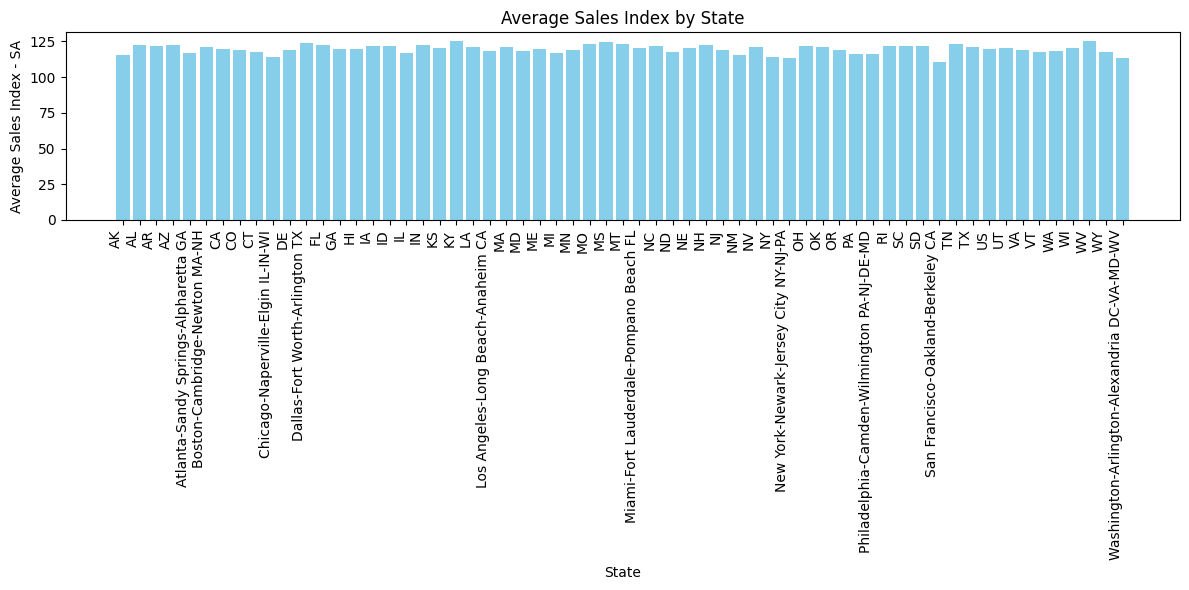

In [15]:
sales_index_by_State = data.groupby('State')['Sales Index - SA'].mean().reset_index()


plt.figure(figsize=(12, 6))
plt.bar(sales_index_by_State['State'], sales_index_by_State['Sales Index - SA'], color='skyblue')
plt.title('Average Sales Index by State')
plt.xlabel('State')
plt.ylabel('Average Sales Index - SA')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

In [16]:
Region = [
    'Atlanta-Sandy Springs-Alpharetta GA',
    'Boston-Cambridge-Newton MA-NH',
    'Chicago-Naperville-Elgin IL-IN-WI',
    'Dallas-Fort Worth-Arlington TX',
    'Los Angeles-Long Beach-Anaheim CA',
    'Miami-Fort Lauderdale-Pompano Beach FL',
    'New York-Newark-Jersey City NY-NJ-PA',
    'Philadelphia-Camden-Wilmington PA-NJ-DE-MD',
    'San Francisco-Oakland-Berkeley CA',
    'Washington-Arlington-Alexandria DC-VA-MD-WV','US'
]

filtered_data = data[data['State'].isin(Region)]
Region_counts = filtered_data['State'].value_counts()
print(Region_counts)


State
US                                             3109
Atlanta-Sandy Springs-Alpharetta GA              61
Boston-Cambridge-Newton MA-NH                    61
Chicago-Naperville-Elgin IL-IN-WI                61
Dallas-Fort Worth-Arlington TX                   61
Los Angeles-Long Beach-Anaheim CA                61
Miami-Fort Lauderdale-Pompano Beach FL           61
New York-Newark-Jersey City NY-NJ-PA             61
Philadelphia-Camden-Wilmington PA-NJ-DE-MD       61
San Francisco-Oakland-Berkeley CA                61
Washington-Arlington-Alexandria DC-VA-MD-WV      61
Name: count, dtype: int64


#### Data Cleaning: Data Filtering

In [17]:
#removing the rows which are in region
data = data[~data['State'].isin(Region)]
data['State'].value_counts()

State
CA    3088
FL    3034
TX    2986
NY    2967
PA    2947
WA    2927
NJ    2914
NC    2885
IL    2881
OH    2872
GA    2864
TN    2760
VA    2751
MA    2739
AZ    2738
MO    2737
MI    2736
MD    2721
CO    2678
IN    2664
MN    2651
CT    2628
NV    2610
LA    2609
OK    2608
OR    2520
SC    2491
WI    2460
KS    2432
AL    2405
AR    2372
KY    2371
NM    2313
UT    2266
IA    2252
HI    2250
MS    2102
AK    2068
NE    2036
ID    2015
ME    2003
RI    1989
NH    1975
DE    1906
WV    1859
MT    1832
SD    1581
WY    1571
ND    1522
VT    1347
Name: count, dtype: int64

#### Data Cleaning: Trimming Whitespace

In [18]:
#Removing the whitespace from the feature name
data.columns = data.columns.str.strip()
data.columns = data.columns.str.replace(r'\s*-\s*', '-', regex=True)
data.columns = data.columns.str.replace(r'\s*%\s*', '%', regex=True)
print(data.columns.tolist())

['State', 'Sector Name', 'Sub-Sector Name', 'Sales Index-SA', 'Transactional Index-SA', 'Sales MOM%-SA', 'Sales YOY%-SA', 'Transaction MOM%-SA', 'Transaction YOY%-SA', 'Sales Index-NSA', 'Transactional Index-NSA', 'Sales MOM%-NSA', 'Sales YOY%-NSA', 'Transaction MOM%-NSA', 'Transaction YOY%-NSA', 'Year', 'Month']


In [19]:
# Group by 'Sector Name' and aggregate 'Sub-Sector Name'
sector_dict = data.groupby('Sector Name')['Sub-Sector Name'].unique().apply(list).to_dict()
# Check the result
print(sector_dict)

{'Accommodation and Food Services': ['Accommodation', 'All', 'Food Services and Drinking Places'], 'Administrative and Support and Waste Management and Remediation Services': ['Administrative and Support Services', 'All'], 'All': ['All'], 'Arts, Entertainment, and Recreation': ['All', 'Amusement, Gambling, and Recreation Industries', 'Performing Arts, Spectator Sports, and Related Industries'], 'Construction': ['All', 'Specialty Trade Contractors'], 'Educational Services': ['All', 'Educational Services'], 'Finance and Insurance': ['All', 'Insurance Carriers and Related Activities'], 'Health Care and Social Assistance': ['All', 'Ambulatory Health Care Services', 'Hospitals'], 'Information': ['All', 'Web Search Portals, Libraries, Archives, and Other Information Services'], 'Manufacturing': ['All', 'Food Manufacturing', 'Transportation Equipment Manufacturing'], 'Other Services (except Public Administration)': ['All', 'Religious, Grantmaking, Civic, Professional, and Similar Organization

In [20]:
sub_sector_int = [
    'All'
]
filtered_data_in = data[data['Sub-Sector Name'].isin(sub_sector_int)]
subsector_name = filtered_data_in['Sub-Sector Name'].value_counts()
print(subsector_name)

Sub-Sector Name
All    42218
Name: count, dtype: int64


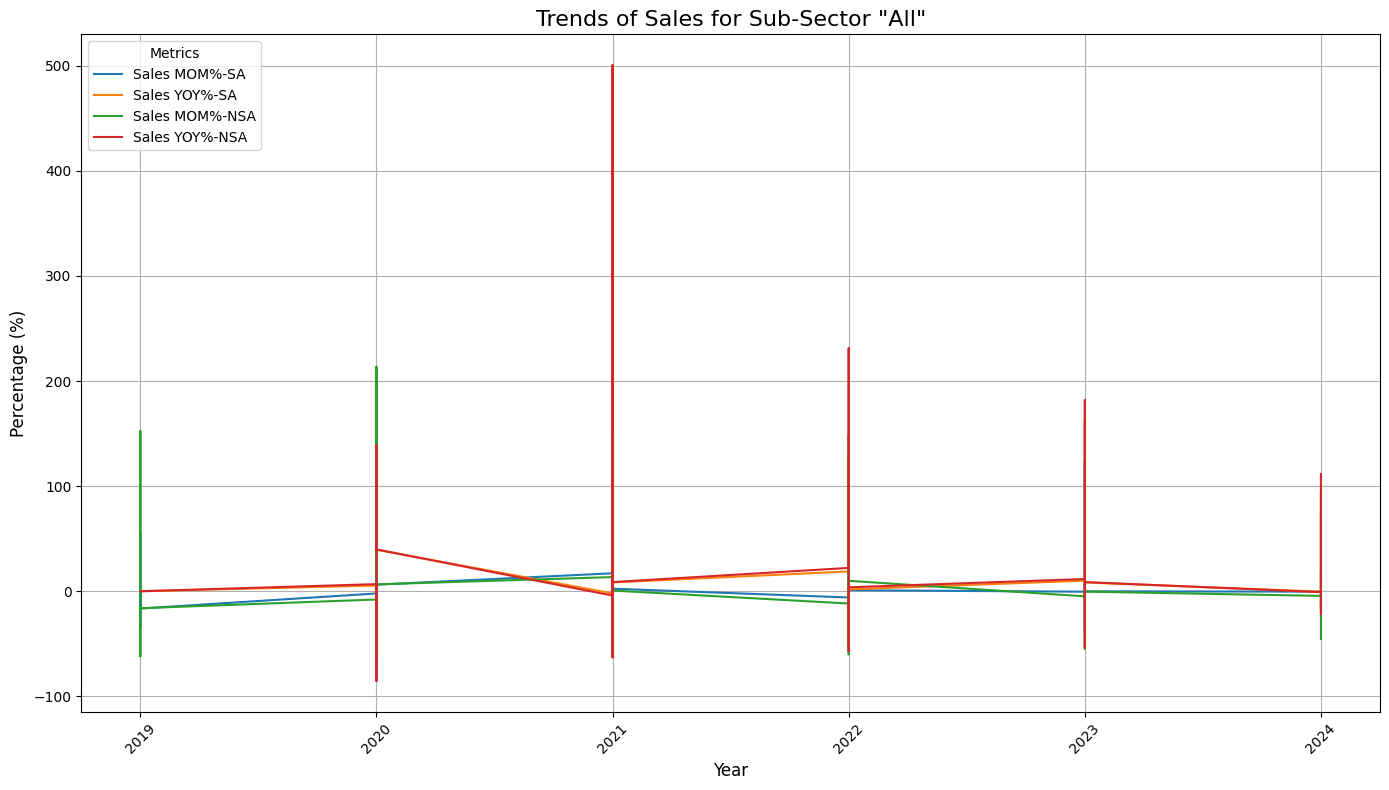

In [21]:
plt.figure(figsize=(14, 8))

columns_to_plot = [
    'Sales MOM%-SA',
    'Sales YOY%-SA',
    'Sales MOM%-NSA',
    'Sales YOY%-NSA',
]

for column in columns_to_plot:
    plt.plot(filtered_data_in['Year'], filtered_data_in[column], label=column)

plt.title('Trends of Sales for Sub-Sector "All"', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Metrics', loc='upper left')
plt.grid()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Data Cleaning: Removing Irrelevant Data

In [22]:
#Remove rows where 'Sub-Sector Name' is 'All'
data = data[data['Sub-Sector Name'] != 'All']

In [23]:
# Group by 'Sector Name' and aggregate 'Sub-Sector Name'
sector_dict = data.groupby('Sector Name')['Sub-Sector Name'].unique().apply(list).to_dict()
print(sector_dict)


{'Accommodation and Food Services': ['Accommodation', 'Food Services and Drinking Places'], 'Administrative and Support and Waste Management and Remediation Services': ['Administrative and Support Services'], 'Arts, Entertainment, and Recreation': ['Amusement, Gambling, and Recreation Industries', 'Performing Arts, Spectator Sports, and Related Industries'], 'Construction': ['Specialty Trade Contractors'], 'Educational Services': ['Educational Services'], 'Finance and Insurance': ['Insurance Carriers and Related Activities'], 'Health Care and Social Assistance': ['Ambulatory Health Care Services', 'Hospitals'], 'Information': ['Web Search Portals, Libraries, Archives, and Other Information Services'], 'Manufacturing': ['Food Manufacturing', 'Transportation Equipment Manufacturing'], 'Other Services (except Public Administration)': ['Religious, Grantmaking, Civic, Professional, and Similar Organizations', 'Repair and Maintenance', 'Personal and Laundry Services'], 'Professional, Scienti

C:\Users\kanna\AppData\Local\Temp\ipykernel_13512\2164631788.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


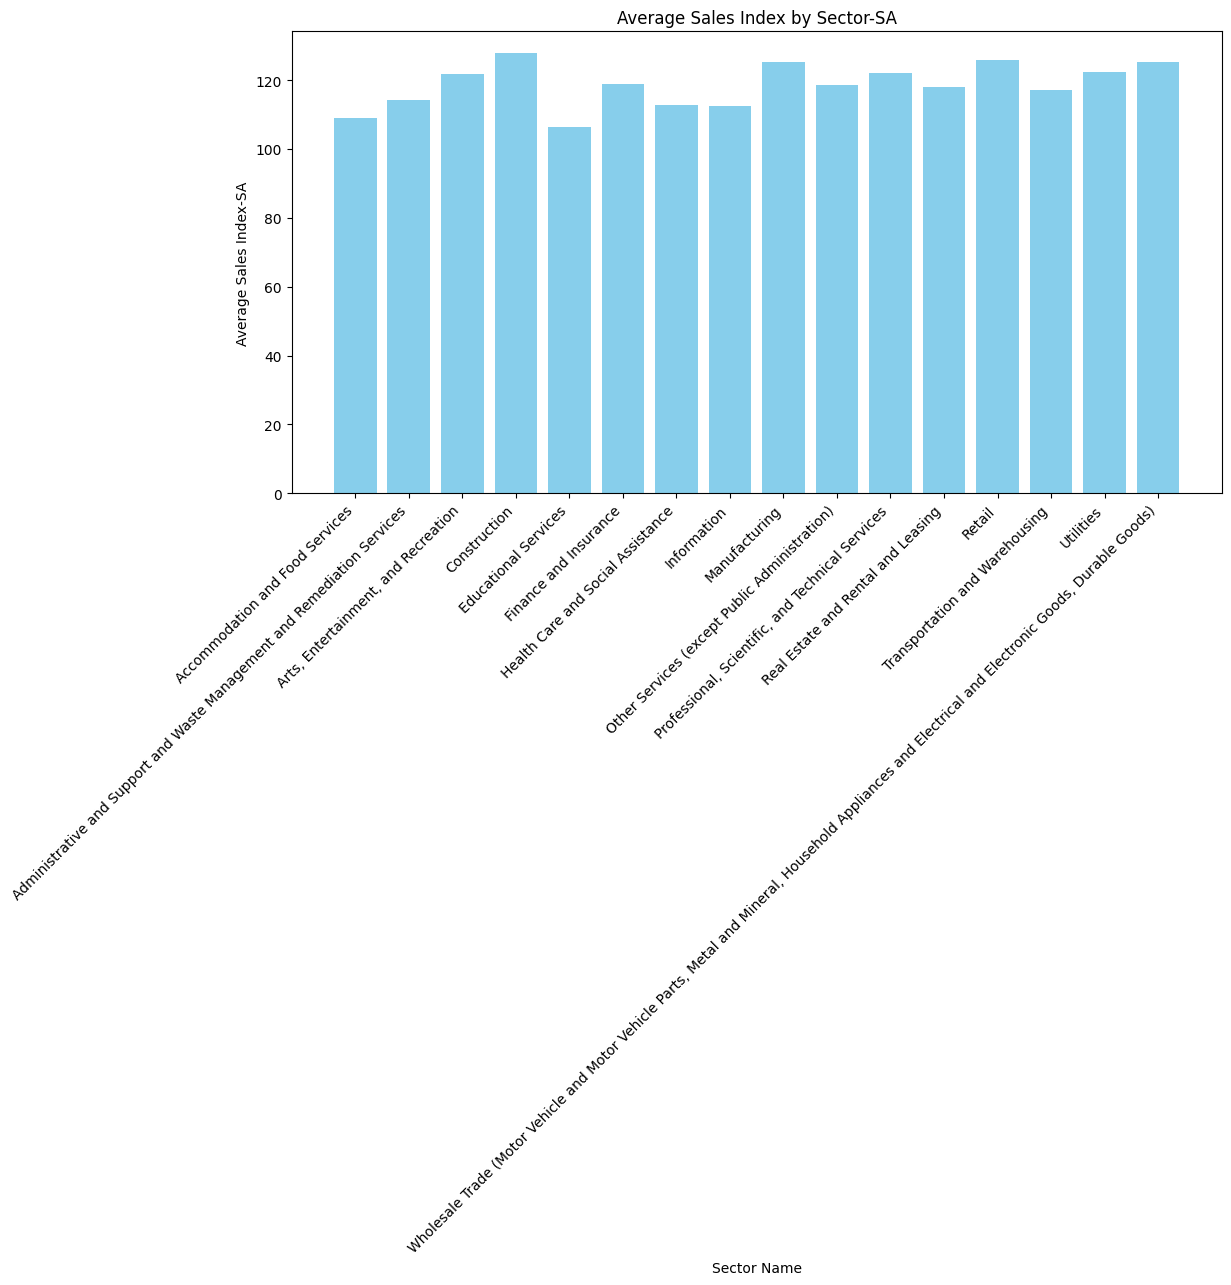

In [24]:
sector_sales_index = data.groupby('Sector Name')['Sales Index-SA'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.bar(sector_sales_index['Sector Name'], sector_sales_index['Sales Index-SA'], color='skyblue')
plt.title('Average Sales Index by Sector-SA')
plt.xlabel('Sector Name')
plt.ylabel('Average Sales Index-SA')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [25]:
# Replace the specific sub-sector name with 'Wholesale Trade' and 'Administrative and Environmental Services'
data['Sector Name'] = data['Sector Name'].replace(
    'Wholesale Trade (Motor Vehicle and Motor Vehicle Parts, Metal and Mineral, Household Appliances and Electrical and Electronic Goods, Durable Goods)',
    'Wholesale Trade'
)

data['Sector Name'] = data['Sector Name'].replace(
    'Administrative and Support and Waste Management and Remediation Services',
    'Administrative and Environmental Services'
)
print(data['Sector Name'].unique())


['Accommodation and Food Services'
 'Administrative and Environmental Services'
 'Arts, Entertainment, and Recreation' 'Construction'
 'Educational Services' 'Health Care and Social Assistance'
 'Other Services (except Public Administration)'
 'Professional, Scientific, and Technical Services'
 'Real Estate and Rental and Leasing' 'Retail'
 'Transportation and Warehousing' 'Utilities' 'Wholesale Trade'
 'Finance and Insurance' 'Manufacturing' 'Information']


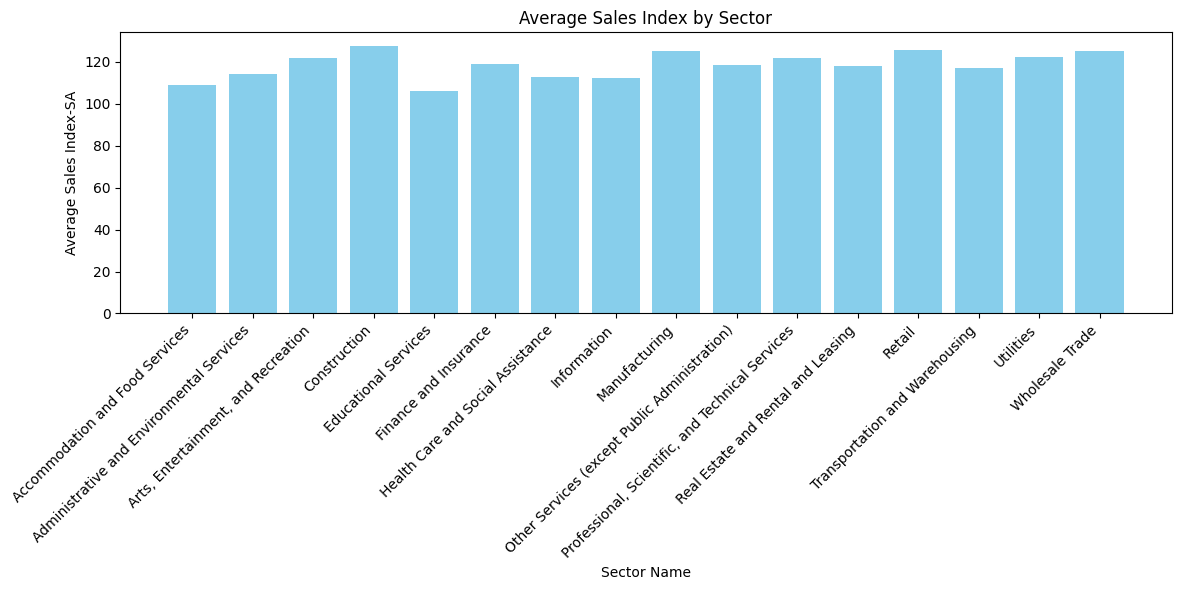

In [26]:
sector_sales_index_one = data.groupby('Sector Name')['Sales Index-SA'].mean().reset_index()

# Create a bar plot
plt.figure(figsize=(12,6))
plt.bar(sector_sales_index_one['Sector Name'], sector_sales_index_one['Sales Index-SA'], color='skyblue')
plt.title('Average Sales Index by Sector')
plt.xlabel('Sector Name')
plt.ylabel('Average Sales Index-SA')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Data Cleaning: Feature Engineering

In [27]:
data['Sales Index']= (data['Sales Index-NSA']+data['Sales Index-SA'])/2
data['Transactional Index']= (data['Transactional Index-NSA']+data['Transactional Index-SA'])/2
data['Transaction MOM %']= (data['Transaction MOM%-NSA']+ data['Transaction MOM%-SA'])/2
data['Transaction YOY %']= (data['Transaction YOY%-NSA']+ data['Transaction YOY%-SA'])/2
data['Sales MOM %']= (data['Sales MOM%-NSA']+data['Sales MOM%-SA'])/2
data['Sales YOY %']= (data['Sales YOY%-NSA']+data['Sales YOY%-SA'])/2
data=data.drop(['Sales Index-NSA','Sales Index-SA','Transactional Index-NSA','Transactional Index-SA','Transaction MOM%-NSA','Transaction MOM%-SA','Transaction YOY%-NSA','Transaction YOY%-SA','Sales MOM%-NSA','Sales MOM%-SA','Sales YOY%-NSA','Sales YOY%-SA'],axis=1)

In [28]:
data.head()

,State,Sector Name,Sub-Sector Name,Year,Month,Sales Index,Transactional Index,Transaction MOM %,Transaction YOY %,Sales MOM %,Sales YOY %
10,AK,Accommodation and Food Services,Accommodation,2019,1,87.170,88.440,0.0,0.0,0.0,0.0
12,AK,Accommodation and Food Services,Food Services and Drinking Places,2019,1,86.075,89.525,0.0,0.0,0.0,0.0
13,AK,Administrative and Environmental Services,Administrative and Support Services,2019,1,84.380,60.560,0.0,0.0,0.0,0.0
17,AK,"Arts, Entertainment, and Recreation","Amusement, Gambling, and Recreation Industries",2019,1,71.840,90.945,0.0,0.0,0.0,0.0
19,AK,Construction,Specialty Trade Contractors,2019,1,86.260,98.155,0.0,0.0,0.0,0.0


In [29]:
data.describe()

,Year,Month,Sales Index,Transactional Index,Transaction MOM %,Transaction YOY %,Sales MOM %,Sales YOY %
count,79715.000000,79715.000000,79715.000000,79715.000000,79715.000000,79715.000000,79715.000000,79715.000000
mean,2021.044245,6.414238,120.754539,108.357624,1.094076,5.736087,1.312738,8.867998
std,1.453112,3.487612,26.949339,26.614752,11.541225,39.420062,10.544988,31.095032
min,2019.000000,1.000000,3.380000,2.130000,-95.020000,-98.015000,-91.270000,-96.960000
25%,2020.000000,3.000000,101.007500,93.450000,-3.685000,-2.840000,-3.745000,0.000000
50%,2021.000000,6.000000,118.055000,104.385000,0.020000,0.000000,0.230000,3.475000
75%,2022.000000,9.000000,138.375000,121.090000,4.605000,10.190000,5.250000,14.245000
max,2024.000000,12.000000,285.135000,286.635000,443.120000,5169.270000,240.645000,4641.550000


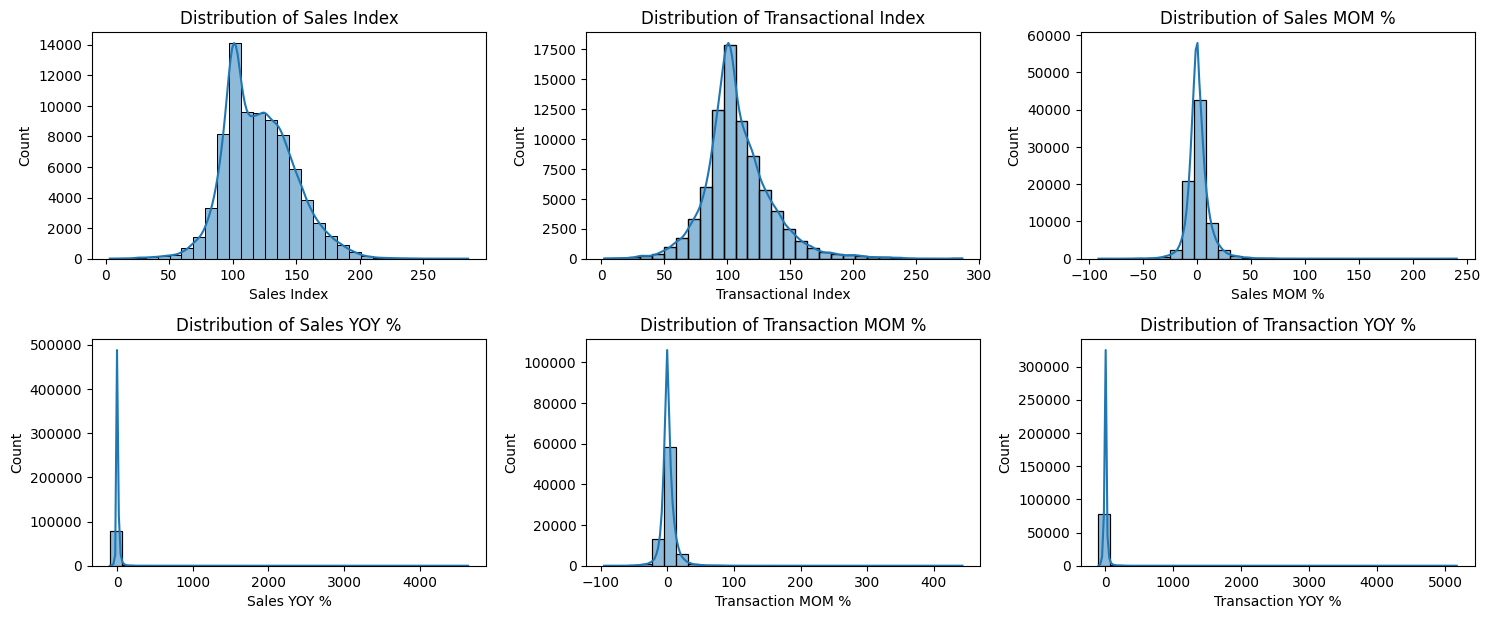

In [30]:
num_cols = [
    'Sales Index', 'Transactional Index', 'Sales MOM %', 'Sales YOY %',
    'Transaction MOM %', 'Transaction YOY %']

plt.figure(figsize=(15, 12))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i)
    sns.histplot(data[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()

plt.show()


#### Data Cleaning: Removing Outliers

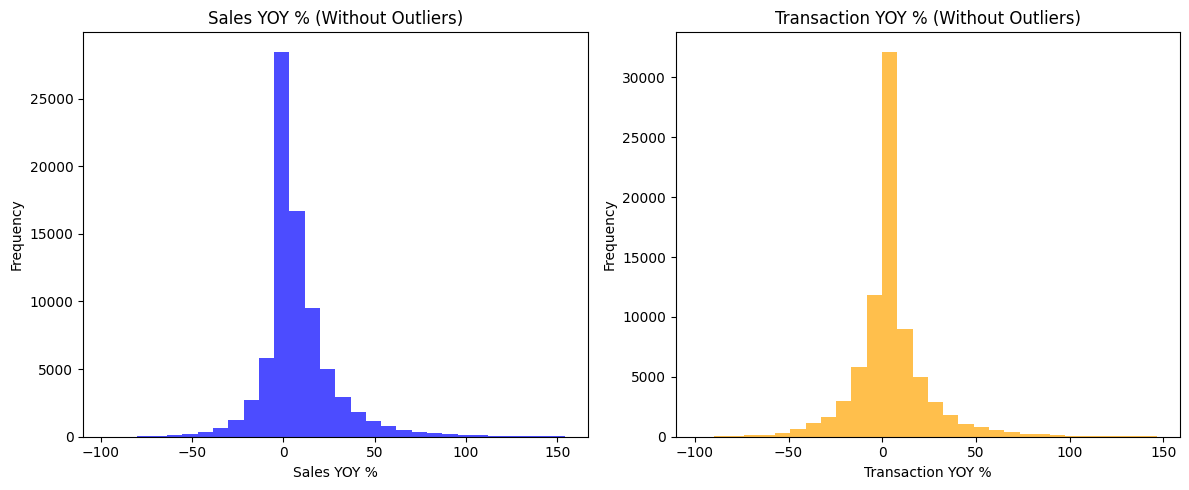

In [31]:
#removing the outliers using inter quartile method
Q1 = data['Sales YOY %'].quantile(0)
Q3 = data['Sales YOY %'].quantile(0.5)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

data = data[(data['Sales YOY %'] >= lower_bound) & (data['Sales YOY %'] <= upper_bound)]

Q1_y = data['Transaction YOY %'].quantile(0)
Q3_y = data['Transaction YOY %'].quantile(0.5)

IQR_y = Q3_y - Q1_y

lower_bound_y = Q1_y - 1.5 * IQR_y
upper_bound_y = Q3_y + 1.5 * IQR_y

data = data[(data['Transaction YOY %'] >= lower_bound_y) & (data['Transaction YOY %'] <= upper_bound_y)]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(data['Sales YOY %'], bins=30, color='blue', alpha=0.7)
plt.title('Sales YOY % (Without Outliers)')
plt.xlabel('Sales YOY %')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(data['Transaction YOY %'], bins=30, color='orange', alpha=0.7)
plt.title('Transaction YOY % (Without Outliers)')
plt.xlabel('Transaction YOY %')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [ ]:
data_upd=data
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 79220 entries, 10 to 127807
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   State                79220 non-null  object 
 1   Sector Name          79220 non-null  object 
 2   Sub-Sector Name      79220 non-null  object 
 3   Year                 79220 non-null  int32  
 4   Month                79220 non-null  int32  
 5   Sales Index          79220 non-null  float64
 6   Transactional Index  79220 non-null  float64
 7   Transaction MOM %    79220 non-null  float64
 8   Transaction YOY %    79220 non-null  float64
 9   Sales MOM %          79220 non-null  float64
 10  Sales YOY %          79220 non-null  float64
dtypes: float64(6), int32(2), object(3)
memory usage: 6.6+ MB


In [33]:
# normalization
data['Sales Index_normalized'] = (data['Sales Index'] - data['Sales Index'].min()) / (data['Sales Index'].max() - data['Sales Index'].min())
data['Transactional Index_normalized'] = (data['Transactional Index'] - data['Transactional Index'].min()) / (data['Transactional Index'].max() - data['Transactional Index'].min())
data['Sales MOM %_normalized'] = (data['Sales MOM %'] - data['Sales MOM %'].min()) / (data['Sales MOM %'].max() - data['Sales MOM %'].min())
data['Sales YOY %_normalized'] = (data['Sales YOY %'] - data['Sales YOY %'].min()) / (data['Sales YOY %'].max() - data['Sales YOY %'].min())
data['Transaction MOM %_normalized'] = (data['Transaction MOM %'] - data['Transaction MOM %'].min()) / (data['Transaction MOM %'].max() - data['Transaction MOM %'].min())
data['Transaction YOY %_normalized'] = (data['Transaction YOY %'] - data['Transaction YOY %'].min()) / (data['Transaction YOY %'].max() - data['Transaction YOY %'].min())

data_scale=data.drop(['Sales Index','Transactional Index','Sales MOM %','Sales YOY %','Transaction MOM %','Transaction YOY %'],axis=1)
data_scale.head()


,State,Sector Name,Sub-Sector Name,Year,Month,Sales Index_normalized,Transactional Index_normalized,Sales MOM %_normalized,Sales YOY %_normalized,Transaction MOM %_normalized,Transaction YOY %_normalized
10,AK,Accommodation and Food Services,Accommodation,2019,1,0.297386,0.303369,0.27498,0.386495,0.176571,0.400478
12,AK,Accommodation and Food Services,Food Services and Drinking Places,2019,1,0.293500,0.307183,0.27498,0.386495,0.176571,0.400478
13,AK,Administrative and Environmental Services,Administrative and Support Services,2019,1,0.287484,0.205374,0.27498,0.386495,0.176571,0.400478
17,AK,"Arts, Entertainment, and Recreation","Amusement, Gambling, and Recreation Industries",2019,1,0.242977,0.312174,0.27498,0.386495,0.176571,0.400478
19,AK,Construction,Specialty Trade Contractors,2019,1,0.294156,0.337516,0.27498,0.386495,0.176571,0.400478


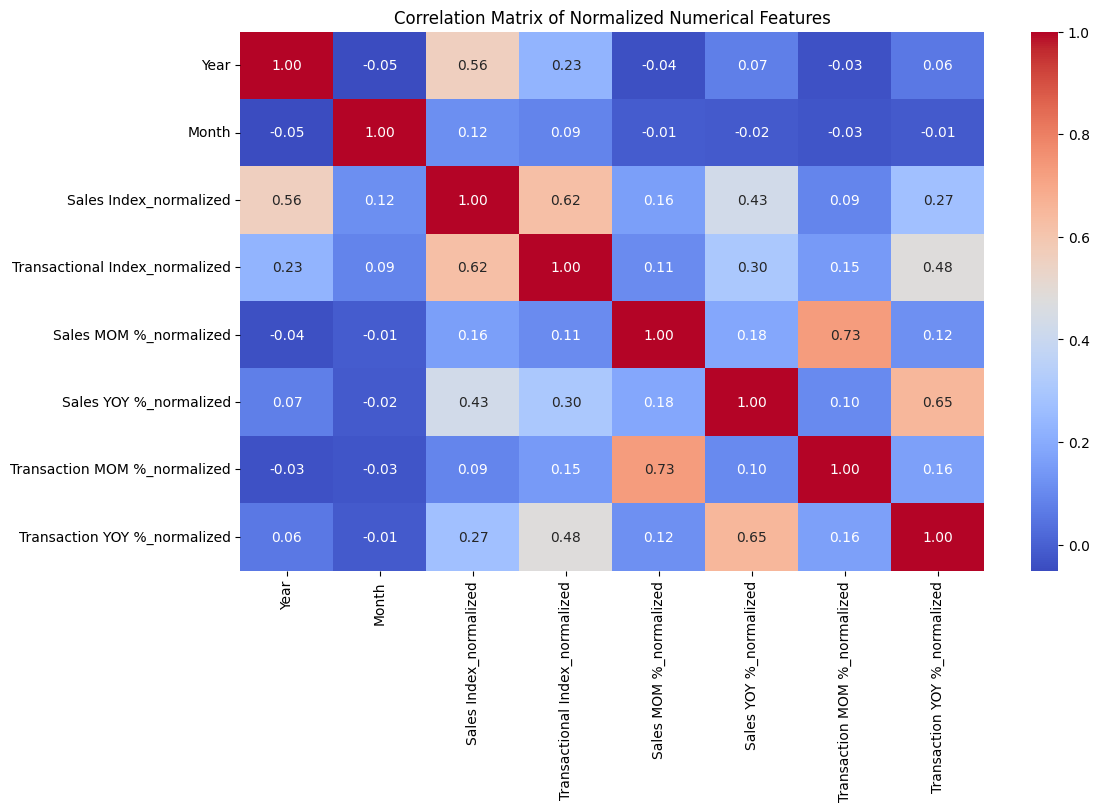

In [34]:
numerical_data = data_scale.select_dtypes(include=['number'])
plt.figure(figsize=(12, 7))
correlation_matrix = numerical_data.corr() 
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Normalized Numerical Features')
plt.show()

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb

### Linear Regression

In [36]:
x= data_scale[['Transactional Index_normalized','Year','Sales YOY %_normalized','Transaction YOY %_normalized']]
y= data_scale['Sales Index_normalized']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(x_train, y_train)
y_pred_lr = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)
print("Linear Regression RMSE:", mean_squared_error(y_test, y_pred_lr))
print("Linear Regression R²:", r2_score(y_test, y_pred_lr))

Linear Regression RMSE: 0.002867367503834195
Linear Regression R²: 0.6821513322025553


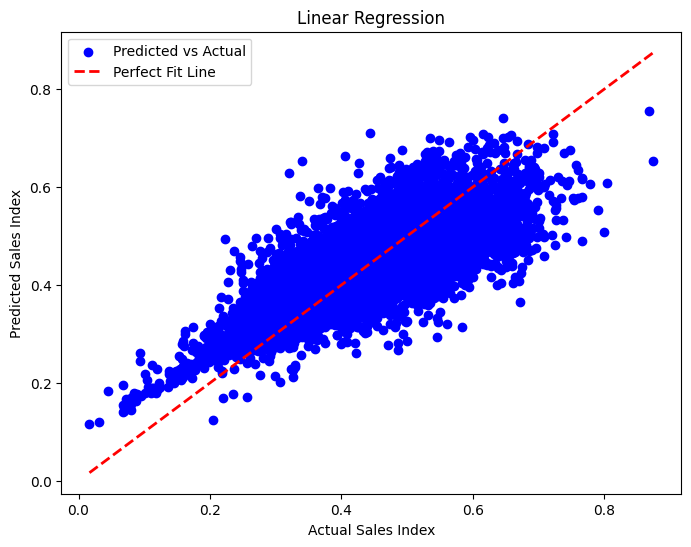

In [37]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit Line')
plt.xlabel('Actual Sales Index')
plt.ylabel('Predicted Sales Index')
plt.title('Linear Regression')
plt.legend()
plt.show()

### Decision Tree Regression

In [38]:
data_enc= pd.get_dummies(data_scale)
y= data_enc['Sales Index_normalized']
x=data_enc.drop(['Sales Index_normalized','Transaction MOM %_normalized'],axis=1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
tree_regressor = DecisionTreeRegressor(random_state=42)
tree_regressor.fit(x_train, y_train)
y_pred_dr = tree_regressor.predict(x_test)
mse = mean_squared_error(y_test, y_pred_dr)
r2 = r2_score(y_test, y_pred_dr)
print("Decision Tree Regression RMSE:", mean_squared_error(y_test, y_pred_dr))
print("Decision Tree Regression R²:", r2_score(y_test, y_pred_dr))

Decision Tree Regression RMSE: 0.0022697537169739514
Decision Tree Regression R²: 0.7483970247260687


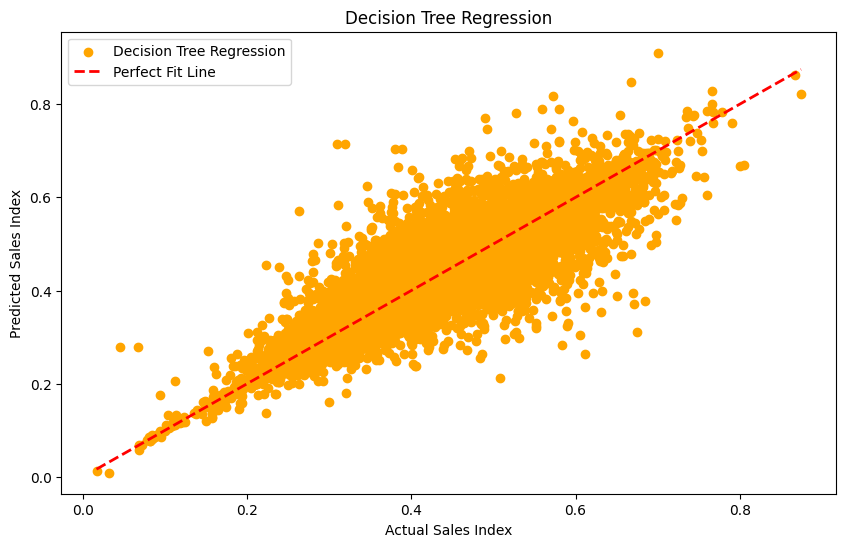

In [39]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_dr, label='Decision Tree Regression', color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit Line')
plt.title('Decision Tree Regression')
plt.xlabel('Actual Sales Index')
plt.ylabel('Predicted Sales Index')
plt.legend()
plt.show()

### Random Forest Regression

In [40]:
data_enc= pd.get_dummies(data_scale)
y= data_enc['Sales Index_normalized']
x=data_enc.drop(['Sales Index_normalized','Transaction MOM %_normalized'],axis=1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
print("Random Forest RMSE:", mean_squared_error(y_test, y_pred_rf))
print("Random Forest R²:", r2_score(y_test, y_pred_rf))

Random Forest RMSE: 0.001122307513605957
Random Forest R²: 0.8755918285389959


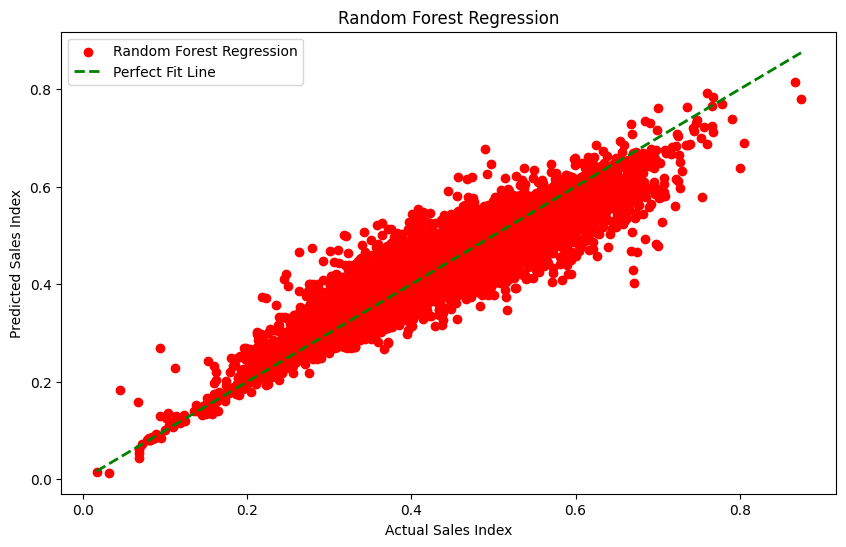

In [41]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, label='Random Forest Regression', color='red')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'g--', lw=2, label='Perfect Fit Line')
plt.title('Random Forest Regression')
plt.xlabel('Actual Sales Index')
plt.ylabel('Predicted Sales Index')
plt.legend()
plt.show()


### Gradient Boosting Regression

In [42]:
y= data_enc['Sales Index_normalized']
x=data_enc.drop(['Sales Index_normalized','Transaction MOM %_normalized'],axis=1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
gb = GradientBoostingRegressor(random_state=42)
gb.fit(x_train, y_train)
y_pred_gb = gb.predict(x_test)
print("Gradient Boosting RMSE:", mean_squared_error(y_test, y_pred_gb))
print("Gradient Boosting R²:", r2_score(y_test, y_pred_gb))

Gradient Boosting RMSE: 0.0020464183234029406
Gradient Boosting R²: 0.773153829434095


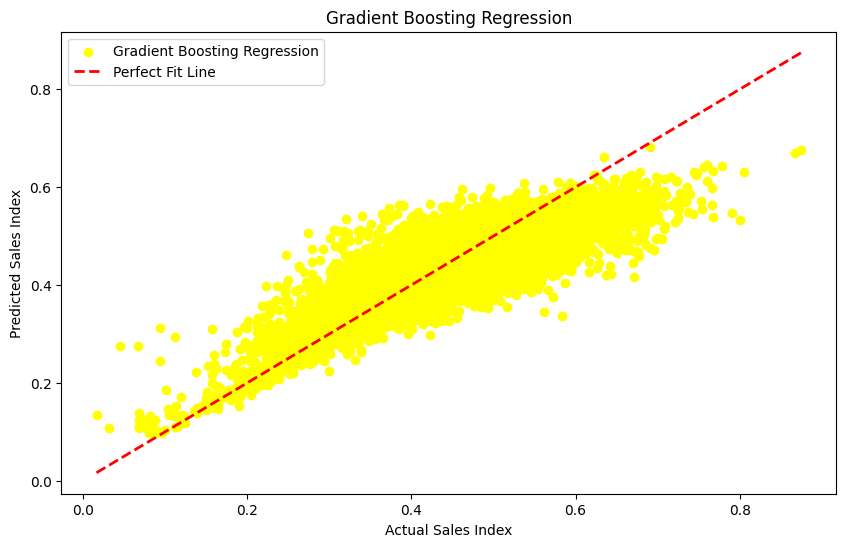

In [43]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test,y_pred_gb, label='Gradient Boosting Regression', color='yellow')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit Line')
plt.title('Gradient Boosting Regression')
plt.xlabel('Actual Sales Index')
plt.ylabel('Predicted Sales Index')
plt.legend()
plt.show()


### XGBoost Regression

In [44]:
data_enc= pd.get_dummies(data_scale)
y= data_enc['Sales Index_normalized']
x=data_enc.drop(['Sales Index_normalized','Transaction MOM %_normalized'],axis=1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
xg_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xg_reg.fit(x_train, y_train)
y_pred_xgb = xg_reg.predict(x_test)
print("XG Boost RMSE:", mean_squared_error(y_test, y_pred_xgb))
print("XG Boost R²:", r2_score(y_test, y_pred_xgb))

XG Boost RMSE: 0.00099898310383746
XG Boost R²: 0.8892623815111584


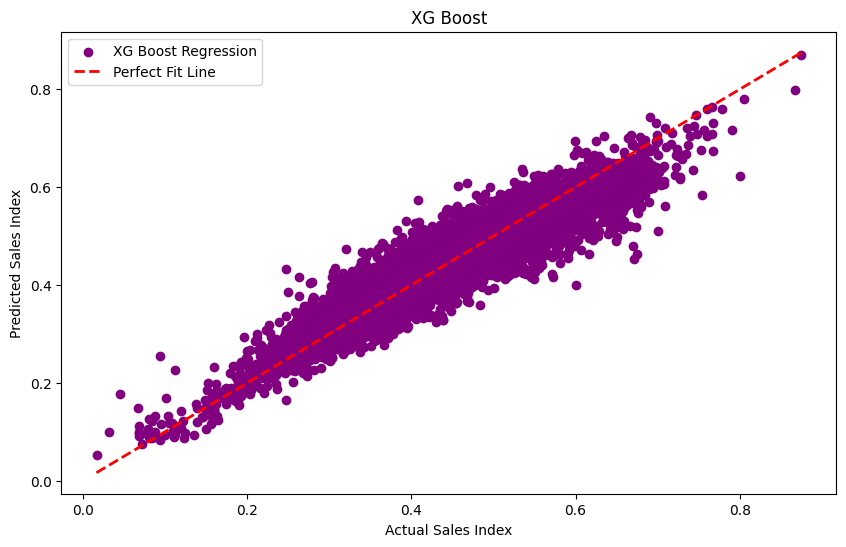

In [45]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_xgb, label='XG Boost Regression', color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit Line')
plt.title('XG Boost')
plt.xlabel('Actual Sales Index')
plt.ylabel('Predicted Sales Index')
plt.legend()
plt.show()

### Bootstrap

In [46]:
from sklearn.utils import resample
def bootstrap_analysis(data, n_iterations=1000):
    results = {}
    for sector in data['Sector Name'].unique():
        sector_data = data[data['Sector Name'] == sector]

        sales_means = []
        transaction_means = []

        for _ in range(n_iterations):
            # Creating a bootstrap sample
            sample = resample(sector_data)
            sales_mean = sample['Sales Index_normalized'].mean()
            transaction_mean = sample['Transactional Index_normalized'].mean()

            sales_means.append(sales_mean)
            transaction_means.append(transaction_mean)

        # Initiating mean and 95% confidence interval for sales and transactions
        sales_mean_ci = np.percentile(sales_means, [2.5, 97.5])
        transaction_mean_ci = np.percentile(transaction_means, [2.5, 97.5])

        results[sector] = {
            'Mean Sales': np.mean(sales_means),
            'Sales CI': sales_mean_ci,
            'Mean Transactions': np.mean(transaction_means),
            'Transaction CI': transaction_mean_ci
        }

    return results
bootstrap_results = bootstrap_analysis(data)
for sector, metrics in bootstrap_results.items():
    print(f"Sector: {sector}")
    print(f"  Mean Sales: {metrics['Mean Sales']:.2f}, 95% CI: {metrics['Sales CI']}")
    print(f"  Mean Transactions: {metrics['Mean Transactions']:.2f}, 95% CI: {metrics['Transaction CI']}")
    print("")

Sector: Accommodation and Food Services
  Mean Sales: 0.37, 95% CI: [0.37160319 0.37593145]
  Mean Transactions: 0.33, 95% CI: [0.331031   0.33404427]

Sector: Administrative and Environmental Services
  Mean Sales: 0.39, 95% CI: [0.38931031 0.39627085]
  Mean Transactions: 0.31, 95% CI: [0.30416235 0.31033365]

Sector: Arts, Entertainment, and Recreation
  Mean Sales: 0.42, 95% CI: [0.412749   0.42029284]
  Mean Transactions: 0.40, 95% CI: [0.39814228 0.40615467]

Sector: Construction
  Mean Sales: 0.44, 95% CI: [0.43952229 0.44659257]
  Mean Transactions: 0.40, 95% CI: [0.39434405 0.40021705]

Sector: Educational Services
  Mean Sales: 0.37, 95% CI: [0.36341732 0.3695124 ]
  Mean Transactions: 0.34, 95% CI: [0.33490011 0.34226151]

Sector: Health Care and Social Assistance
  Mean Sales: 0.39, 95% CI: [0.38620198 0.39071127]
  Mean Transactions: 0.34, 95% CI: [0.33851108 0.34171271]

Sector: Other Services (except Public Administration)
  Mean Sales: 0.41, 95% CI: [0.40558529 0.408798

In [47]:
def bootstrap_mean_sales(data, n_iterations=1000):
    means = []
    for _ in range(n_iterations):
        sample = data.sample(frac=1, replace=True)  
        means.append(sample['Sales Index_normalized'].mean())  
    return means

overall_bootstrap_results = {}
sectors_to_check = ['Construction', 'Retail']


for sector in sectors_to_check:
    sector_data = data[data['Sector Name'] == sector]
    bootstrap_results = {}
    regions = sector_data['State'].unique()  
    for region in regions:
        region_data = sector_data[sector_data['State'] == region]
        if not region_data.empty:  
            bootstrap_means = bootstrap_mean_sales(region_data)
            bootstrap_results[region] = {
                'mean_sales': np.mean(bootstrap_means),
                'ci': np.percentile(bootstrap_means, [2.5, 97.5])  
            }


    bootstrap_df = pd.DataFrame(bootstrap_results).T
    bootstrap_df.columns = ['Mean Sales', '95% CI']

    bootstrap_df['Mean Sales'] = pd.to_numeric(bootstrap_df['Mean Sales'], errors='coerce')
    bootstrap_df = bootstrap_df.dropna(subset=['Mean Sales'])

    best_region = bootstrap_df['Mean Sales'].idxmax()
    best_mean_sales = bootstrap_df['Mean Sales'].max()
    best_ci = bootstrap_df.loc[best_region, '95% CI']

    overall_bootstrap_results[sector] = {
        'Best Region': best_region,
        'Mean Sales': best_mean_sales,
        '95% CI': best_ci
    }

    print(f"Sector: {sector}")
    print(f"Best Region: {best_region}")
    print(f"Mean Sales: {best_mean_sales:.4f}, 95% CI: {best_ci}")
    print("")

Sector: Construction
Best Region: MT
Mean Sales: 0.5115, 95% CI: [0.48353274 0.54031437]

Sector: Retail
Best Region: MS
Mean Sales: 0.4627, 95% CI: [0.45370536 0.47235219]



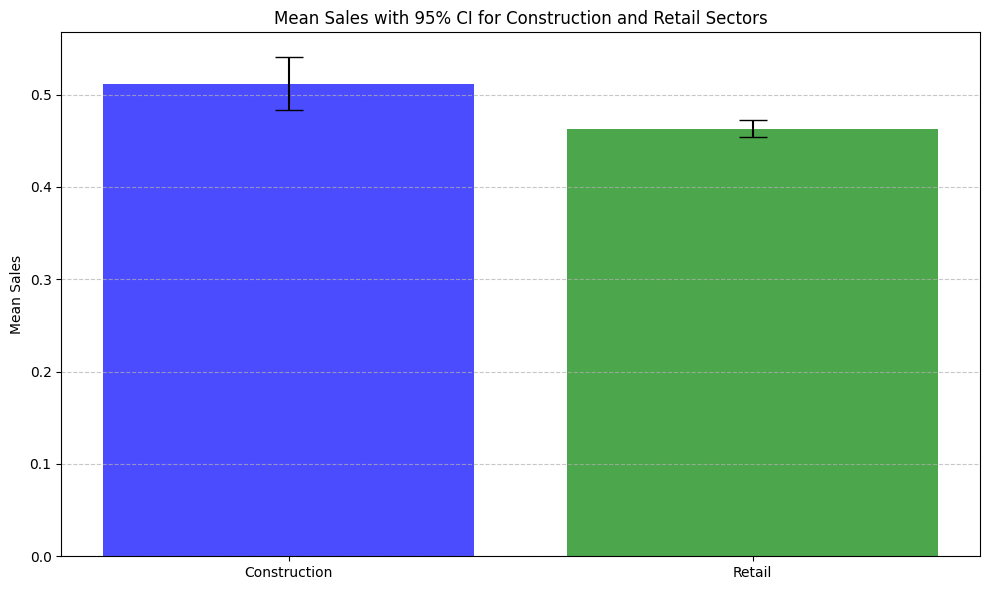

In [48]:
def plot_bar_bootstrap_results(results):
    sectors = list(results.keys())
    mean_sales = [results[sector]['Mean Sales'] for sector in sectors]
    ci_lower = [results[sector]['Mean Sales'] - results[sector]['95% CI'][0] for sector in sectors]
    ci_upper = [results[sector]['95% CI'][1] - results[sector]['Mean Sales'] for sector in sectors]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(sectors, mean_sales, yerr=[ci_lower, ci_upper], capsize=10, color=['blue', 'green'], alpha=0.7)
    ax.set_ylabel('Mean Sales')
    ax.set_title('Mean Sales with 95% CI for Construction and Retail Sectors')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
plot_bar_bootstrap_results(overall_bootstrap_results)

In [49]:
import joblib
joblib.dump(xg_reg, 'xg_reg_model.pkl')

['xg_reg_model.pkl']

In [50]:
print('Transactional_min',data_upd['Transactional Index'].min())
print('Transactional_max',data_upd['Transactional Index'].max())
print('Sales Index_min',data_upd['Sales Index'].min())
print('Sales Index_max',data_upd['Sales Index'].max())
print( 'Transaction YOY_min',data_upd['Transaction YOY %'].min())
print( 'Transaction YOY_max',data_upd['Transaction YOY %'].max())
print( 'Sales YOY_min',data_upd['Sales YOY %'].min())
print( 'Sales YOY_max',data_upd['Sales YOY %'].max())

Transactional_min 2.13
Transactional_max 286.635
Sales Index_min 3.38
Sales Index_max 285.135
Transaction YOY_min -98.015
Transaction YOY_max 146.73000000000002
Sales YOY_min -96.96
Sales YOY_max 153.91


In [51]:
feature_names = xg_reg.get_booster().feature_names
print(feature_names)

['Year', 'Month', 'Transactional Index_normalized', 'Sales MOM %_normalized', 'Sales YOY %_normalized', 'Transaction YOY %_normalized', 'State_AK', 'State_AL', 'State_AR', 'State_AZ', 'State_CA', 'State_CO', 'State_CT', 'State_DE', 'State_FL', 'State_GA', 'State_HI', 'State_IA', 'State_ID', 'State_IL', 'State_IN', 'State_KS', 'State_KY', 'State_LA', 'State_MA', 'State_MD', 'State_ME', 'State_MI', 'State_MN', 'State_MO', 'State_MS', 'State_MT', 'State_NC', 'State_ND', 'State_NE', 'State_NH', 'State_NJ', 'State_NM', 'State_NV', 'State_NY', 'State_OH', 'State_OK', 'State_OR', 'State_PA', 'State_RI', 'State_SC', 'State_SD', 'State_TN', 'State_TX', 'State_UT', 'State_VA', 'State_VT', 'State_WA', 'State_WI', 'State_WV', 'State_WY', 'Sector Name_Accommodation and Food Services', 'Sector Name_Administrative and Environmental Services', 'Sector Name_Arts, Entertainment, and Recreation', 'Sector Name_Construction', 'Sector Name_Educational Services', 'Sector Name_Finance and Insurance', 'Sector 